In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

runs = pd.read_csv('../data/processed/runs.csv', parse_dates=['date'])
features = pd.read_csv('../data/processed/features.csv', parse_dates=['date'])

# ── Define your race results manually ────────────────────────────────────────
# distance_km, time_min, notes
# Exclude the 1600m (too short) and triathlon leg (partial effort)
races = pd.DataFrame([
    {'date': '2023-09-11', 'distance_km': 5.02, 'time_min': 26.93, 'name': 'Garneau Parkrun'},
    {'date': '2024-04-18', 'distance_km': 4.34, 'time_min': 19.57, 'name': "Frank's Race 1"},
    {'date': '2024-04-25', 'distance_km': 4.48, 'time_min': 20.02, 'name': "Frank's Race 2"},
    {'date': '2024-09-07', 'distance_km': 5.01, 'time_min': 21.18, 'name': 'Edmonton Parkrun'},
    {'date': '2025-10-11', 'distance_km': 5.07, 'time_min': 21.02, 'name': 'Parkrun with Mak'},
])
races['date'] = pd.to_datetime(races['date'])
races['pace_min_km'] = races['time_min'] / races['distance_km']

print("Your race results:")
print(races[['date','name','distance_km','time_min','pace_min_km']].to_string(index=False))

Your race results:
      date             name  distance_km  time_min  pace_min_km
2023-09-11  Garneau Parkrun         5.02     26.93     5.364542
2024-04-18   Frank's Race 1         4.34     19.57     4.509217
2024-04-25   Frank's Race 2         4.48     20.02     4.468750
2024-09-07 Edmonton Parkrun         5.01     21.18     4.227545
2025-10-11 Parkrun with Mak         5.07     21.02     4.145957


In [4]:
# ── VDOT calculation ──────────────────────────────────────────────────────────
# Jack Daniels' VDOT is a performance-based VO2max proxy
# Formula: from Daniels & Gilbert 1979, implemented below
# Given a race time at a known distance, compute VDOT
# Then use VDOT to predict equivalent performance at any other distance

def vdot_from_race(distance_m, time_min):
    """
    Estimate VDOT from a race performance.
    distance_m: race distance in metres
    time_min: finish time in minutes
    Returns VDOT (ml/kg/min equivalent)
    """
    # Oxygen cost of running at race pace
    # velocity in metres per minute
    v = distance_m / time_min
    
    # VO2 at race velocity (Daniels formula)
    vo2 = -4.60 + 0.182258 * v + 0.000104 * v**2
    
    # Percent VO2max utilised at race duration
    # (longer races use a lower % of max)
    pct_max = (0.8 + 0.1894393 * np.exp(-0.012778 * time_min)
                   + 0.2989558 * np.exp(-0.1932605 * time_min))
    
    return vo2 / pct_max


def predict_time_from_vdot(vdot, distance_m):
    """
    Given VDOT, predict finish time at a target distance.
    Uses Newton's method to invert the VDOT formula numerically.
    Returns predicted time in minutes.
    """
    # Initial guess: assume 5:00/km pace
    t = distance_m / 1000 * 5.0
    
    for _ in range(50):   # Newton iterations
        v      = distance_m / t
        vo2    = -4.60 + 0.182258 * v + 0.000104 * v**2
        pct    = (0.8 + 0.1894393 * np.exp(-0.012778 * t)
                      + 0.2989558 * np.exp(-0.1932605 * t))
        f      = vo2 / pct - vdot

        # Numerical derivative
        dt     = 0.001
        v2     = distance_m / (t + dt)
        vo2_2  = -4.60 + 0.182258 * v2 + 0.000104 * v2**2
        pct_2  = (0.8 + 0.1894393 * np.exp(-0.012778 * (t+dt))
                      + 0.2989558 * np.exp(-0.1932605 * (t+dt)))
        f2     = vo2_2 / pct_2 - vdot
        df     = (f2 - f) / dt

        t = t - f / df
        if abs(f) < 1e-8:
            break
    return t


# Compute VDOT for each race
races['vdot'] = races.apply(
    lambda r: vdot_from_race(r['distance_km'] * 1000, r['time_min']), axis=1)

print("VDOT per race:")
print(races[['date','name','time_min','vdot']].to_string(index=False))
print(f"\nVDOT range: {races['vdot'].min():.1f} – {races['vdot'].max():.1f}")
print(f"Mean VDOT:  {races['vdot'].mean():.1f}")

# What does mean VDOT predict for common distances?
mean_vdot = races['vdot'].mean()
print(f"\nPredictions at mean VDOT ({mean_vdot:.1f}):")
for dist_km in [1.0, 3.0, 5.0, 10.0, 21.1]:
    t = predict_time_from_vdot(mean_vdot, dist_km * 1000)
    mins = int(t)
    secs = int((t - mins) * 60)
    pace = t / dist_km
    print(f"  {dist_km:5.1f} km → {mins}:{secs:02d}  ({pace:.2f} min/km)")

VDOT per race:
      date             name  time_min      vdot
2023-09-11  Garneau Parkrun     26.93 35.246813
2024-04-18   Frank's Race 1     19.57 42.892536
2024-04-25   Frank's Race 2     20.02 43.437882
2024-09-07 Edmonton Parkrun     21.18 46.688440
2025-10-11 Parkrun with Mak     21.02 47.802759

VDOT range: 35.2 – 47.8
Mean VDOT:  43.2

Predictions at mean VDOT (43.2):
    1.0 km → 3:56  (3.94 min/km)
    3.0 km → 13:07  (4.37 min/km)
    5.0 km → 22:34  (4.51 min/km)
   10.0 km → 46:49  (4.68 min/km)
   21.1 km → 103:48  (4.92 min/km)


In [5]:
# ── Join race data with training load features ────────────────────────────────
# For each race, look up what the training load was on that day
# This is where the ML part comes in — does CTL predict VDOT performance?

race_features = []
for _, race in races.iterrows():
    # Find the matching row in features.csv by date
    match = features[features['date'].dt.normalize() == race['date'].normalize()]
    if len(match) > 0:
        row = match.iloc[0]
        race_features.append({
            'date':       race['date'],
            'name':       race['name'],
            'distance_km': race['distance_km'],
            'time_min':   race['time_min'],
            'vdot':       race['vdot'],
            'ctl_pre':    row['ctl_pre'],
            'atl_pre':    row['atl_pre'],
            'tsb_pre':    row['tsb_pre'],
            'weekly_km':  row['weekly_km_7d'],
        })

race_df = pd.DataFrame(race_features)
print("Race data with training load context:")
print(race_df[['date','name','vdot','ctl_pre','atl_pre','tsb_pre']].to_string(index=False))

Race data with training load context:
      date             name      vdot  ctl_pre  atl_pre   tsb_pre
2023-09-11  Garneau Parkrun 35.246813 0.330200 0.020571  0.309629
2024-04-18   Frank's Race 1 42.892536 1.915772 0.862163  1.053609
2024-04-25   Frank's Race 2 43.437882 1.524310 0.308192  1.216118
2024-09-07 Edmonton Parkrun 46.688440 0.851472 0.032873  0.818599
2025-10-11 Parkrun with Mak 47.802759 2.836557 5.132486 -2.295929


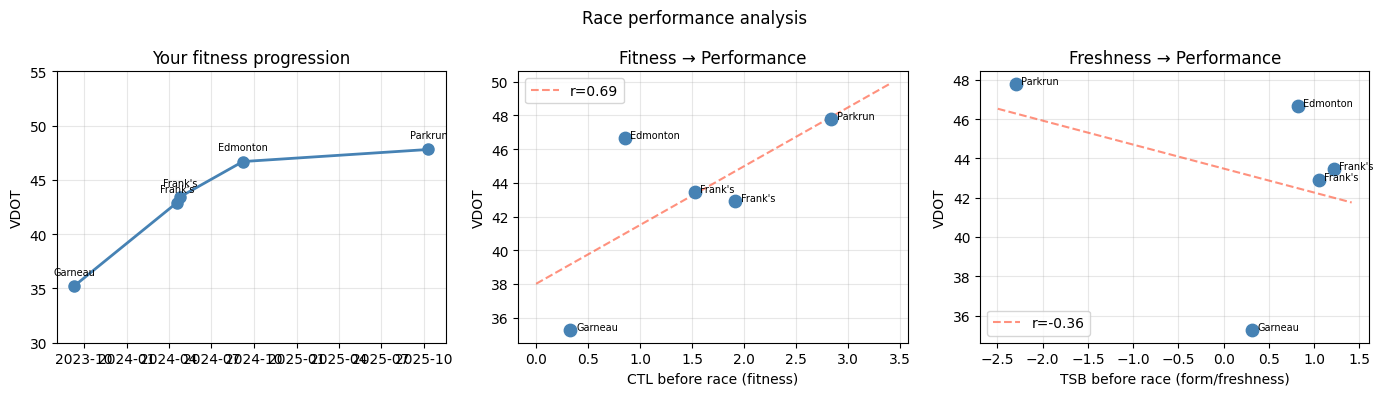

CTL → VDOT:  r=0.686  (p=0.201)
TSB → VDOT:  r=-0.359  (p=0.553)


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# ── Visualise the key relationships ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. VDOT over time — your fitness progression
axes[0].plot(race_df['date'], race_df['vdot'], 
             'o-', color='steelblue', markersize=8, linewidth=2)
for _, row in race_df.iterrows():
    axes[0].annotate(row['name'].split()[0], 
                     (row['date'], row['vdot']),
                     textcoords='offset points', xytext=(0, 8),
                     fontsize=7, ha='center')
axes[0].set_ylabel('VDOT')
axes[0].set_title('Your fitness progression')
axes[0].set_ylim(30, 55)
axes[0].grid(alpha=0.3)

# 2. CTL vs VDOT — does fitness predict performance?
axes[1].scatter(race_df['ctl_pre'], race_df['vdot'],
                s=80, color='steelblue', zorder=3)
for _, row in race_df.iterrows():
    axes[1].annotate(row['name'].split()[0],
                     (row['ctl_pre'], row['vdot']),
                     textcoords='offset points', xytext=(4, 0), fontsize=7)
# Fit a line
slope, intercept, r, p, _ = stats.linregress(race_df['ctl_pre'], race_df['vdot'])
x_line = np.linspace(0, race_df['ctl_pre'].max() * 1.2, 100)
axes[1].plot(x_line, slope * x_line + intercept, 
             '--', color='tomato', alpha=0.7, label=f'r={r:.2f}')
axes[1].set_xlabel('CTL before race (fitness)')
axes[1].set_ylabel('VDOT')
axes[1].set_title('Fitness → Performance')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. TSB vs VDOT — does freshness predict performance?
axes[2].scatter(race_df['tsb_pre'], race_df['vdot'],
                s=80, color='steelblue', zorder=3)
for _, row in race_df.iterrows():
    axes[2].annotate(row['name'].split()[0],
                     (row['tsb_pre'], row['vdot']),
                     textcoords='offset points', xytext=(4, 0), fontsize=7)
slope2, intercept2, r2, p2, _ = stats.linregress(race_df['tsb_pre'], race_df['vdot'])
x_line2 = np.linspace(race_df['tsb_pre'].min() - 0.2, race_df['tsb_pre'].max() + 0.2, 100)
axes[2].plot(x_line2, slope2 * x_line2 + intercept2,
             '--', color='tomato', alpha=0.7, label=f'r={r2:.2f}')
axes[2].set_xlabel('TSB before race (form/freshness)')
axes[2].set_ylabel('VDOT')
axes[2].set_title('Freshness → Performance')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Race performance analysis', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/race_analysis.png', dpi=120)
plt.show()

print(f"CTL → VDOT:  r={r:.3f}  (p={p:.3f})")
print(f"TSB → VDOT:  r={r2:.3f}  (p={p2:.3f})")

In [8]:
# ── Build the race predictor ──────────────────────────────────────────────────

def estimate_current_vdot(race_df, current_ctl, current_date=None):
    """
    Estimate current VDOT given training load context.
    
    Strategy:
    1. Weight each past race by recency and CTL similarity
    2. Adjust upward if current CTL > race CTL (fitter now)
    3. Return estimate with uncertainty bounds
    
    With only 5 races we use a weighted average, not a regression.
    This is honest — we don't overfit a line to 5 points.
    """
    import pandas as pd
    
    if current_date is None:
        current_date = pd.Timestamp.now()
    
    df = race_df.copy()
    
    # Recency weight — more recent races matter more
    # Half-life of 180 days: a race 180 days ago gets half the weight
    days_ago = (current_date - df['date']).dt.days.values
    recency_weight = np.exp(-days_ago / 180)
    
    # CTL similarity weight — races run at similar fitness are more predictive
    # Avoid division by zero if CTL values are identical
    ctl_range = df['ctl_pre'].max() - df['ctl_pre'].min()
    if ctl_range > 0:
        ctl_diff = np.abs(df['ctl_pre'].values - current_ctl)
        ctl_weight = np.exp(-ctl_diff / (ctl_range * 0.5))
    else:
        ctl_weight = np.ones(len(df))
    
    # Combined weight
    weights = recency_weight * ctl_weight
    weights = weights / weights.sum()
    
    # Weighted VDOT estimate from past races
    base_vdot = np.average(df['vdot'].values, weights=weights)
    
    # CTL adjustment — if you're fitter now than at your reference races,
    # adjust VDOT upward. We use the CTL→VDOT slope from the data,
    # but cap it to avoid overconfident extrapolation
    # Slope from our regression: ~4.1 VDOT per CTL unit
    # We use a conservative 3.0 to avoid overclaiming
    weighted_ctl = np.average(df['ctl_pre'].values, weights=weights)
    ctl_delta = current_ctl - weighted_ctl
    ctl_adjustment = np.clip(ctl_delta * 3.0, -5.0, 5.0)  # cap at ±5 VDOT
    
    adjusted_vdot = base_vdot + ctl_adjustment
    
    # Uncertainty: std of weighted residuals + model uncertainty
    # With 5 races we're honest about wide bounds
    residuals = df['vdot'].values - base_vdot
    weighted_std = np.sqrt(np.average(residuals**2, weights=weights))
    uncertainty = max(weighted_std, 1.5)  # minimum ±1.5 VDOT
    
    return {
        'vdot_estimate':  adjusted_vdot,
        'vdot_low':       adjusted_vdot - uncertainty,
        'vdot_high':      adjusted_vdot + uncertainty,
        'base_vdot':      base_vdot,
        'ctl_adjustment': ctl_adjustment,
        'uncertainty':    uncertainty,
        'most_similar_race': df.loc[weights.argmax(), 'name'],
    }


def predict_race_times(vdot_result, distances_km=None):
    """
    Given a VDOT estimate with uncertainty, predict finish times
    at common race distances with confidence ranges.
    """
    if distances_km is None:
        distances_km = [1.0, 3.0, 5.0, 10.0, 21.1]
    
    predictions = []
    for dist in distances_km:
        t_est  = predict_time_from_vdot(vdot_result['vdot_estimate'], dist * 1000)
        t_fast = predict_time_from_vdot(vdot_result['vdot_high'],     dist * 1000)
        t_slow = predict_time_from_vdot(vdot_result['vdot_low'],      dist * 1000)
        
        def fmt(t):
            if t >= 60:
                h = int(t // 60)
                m = int(t % 60)
                s = int((t - int(t)) * 60)
                return f"{h}:{m:02d}:{s:02d}"
            else:
                m = int(t)
                s = int((t - m) * 60)
                return f"{m}:{s:02d}"
        
        predictions.append({
            'distance_km': dist,
            'predicted':   fmt(t_est),
            'fast_bound':  fmt(t_fast),
            'slow_bound':  fmt(t_slow),
            'pace_min_km': t_est / dist,
        })
    
    return pd.DataFrame(predictions)


# ── Test with current training state ─────────────────────────────────────────
# Use the most recent CTL from your features table
latest = features.sort_values('date').iloc[-1]
current_ctl = latest['ctl_pre']
current_date = latest['date']

print(f"Current training state ({current_date.date()}):")
print(f"  CTL: {current_ctl:.2f}  ATL: {latest['atl_pre']:.2f}  TSB: {latest['tsb_pre']:+.2f}")
print(f"  Weekly km: {latest['weekly_km_7d']:.1f}")

vdot_est = estimate_current_vdot(race_df, current_ctl, current_date)

print(f"\nVDOT estimate:")
print(f"  Base (from weighted races): {vdot_est['base_vdot']:.1f}")
print(f"  CTL adjustment:            {vdot_est['ctl_adjustment']:+.1f}")
print(f"  Final estimate:            {vdot_est['vdot_estimate']:.1f}")
print(f"  Range:                     {vdot_est['vdot_low']:.1f} – {vdot_est['vdot_high']:.1f}")
print(f"  Most similar race:         {vdot_est['most_similar_race']}")

print(f"\nRace time predictions:")
preds = predict_race_times(vdot_est)
for _, row in preds.iterrows():
    print(f"  {row['distance_km']:5.1f} km  →  {row['predicted']:>8}  "
          f"(range: {row['fast_bound']} – {row['slow_bound']})  "
          f"@ {row['pace_min_km']:.2f} min/km")

Current training state (2026-04-12):
  CTL: 0.59  ATL: 2.25  TSB: -1.67
  Weekly km: 9.0

VDOT estimate:
  Base (from weighted races): 46.4
  CTL adjustment:            -4.3
  Final estimate:            42.1
  Range:                     39.4 – 44.8
  Most similar race:         Parkrun with Mak

Race time predictions:
    1.0 km  →      4:01  (range: 3:48 – 4:16)  @ 4.03 min/km
    3.0 km  →     13:25  (range: 12:42 – 14:12)  @ 4.47 min/km
    5.0 km  →     23:05  (range: 21:53 – 24:24)  @ 4.62 min/km
   10.0 km  →     47:52  (range: 45:24 – 50:39)  @ 4.79 min/km
   21.1 km  →   1:46:10  (range: 1:40:39 – 1:52:21)  @ 5.03 min/km


In [9]:
# ── Training Readiness Score ──────────────────────────────────────────────────
# Garmin's version uses HRV — we don't have that.
# Ours uses TSB, recent load trend, rest pattern, and HR drift.
# Output: 0–100 score with a category and plain-English explanation.

def compute_readiness(features_row, race_df=None):
    """
    Compute a 0-100 training readiness score from training load features.
    
    Components:
    1. Form (TSB) — are you fresh or fatigued?           weight 0.40
    2. Fitness (CTL trend) — is fitness building?        weight 0.25  
    3. Rest (days since last run) — adequate recovery?   weight 0.20
    4. Load stability (week delta) — sustainable ramp?   weight 0.15
    
    Each component is normalised to 0-100 before weighting.
    """
    
    tsb        = features_row.get('tsb_pre',             0.0)
    ctl        = features_row.get('ctl_pre',             0.0)
    atl        = features_row.get('atl_pre',             0.0)
    days_rest  = features_row.get('days_since_last_run', 1.0)
    wk_delta   = features_row.get('weekly_km_delta_pct', 0.0)
    weekly_km  = features_row.get('weekly_km_7d',        0.0)

    scores = {}
    explanations = []

    # ── Component 1: Form (TSB) ───────────────────────────────────────────────
    # TSB range in your data: roughly -4 to +3
    # Peak readiness: TSB around +0.5 to +1.5 (fresh but not detrained)
    # Poor readiness: TSB < -2 (deep fatigue) or TSB > 3 (detrained)
    # Map to 0-100 with peak at TSB=+1
    if pd.isna(tsb):
        scores['form'] = 50
    else:
        # Gaussian-shaped scoring — peaks at TSB=+1, falls off both sides
        # Width parameter controls how quickly score drops
        form_score = 100 * np.exp(-((tsb - 1.0) ** 2) / (2 * 1.5**2))
        scores['form'] = np.clip(form_score, 0, 100)
    
    if tsb < -2:
        explanations.append("high accumulated fatigue")
    elif tsb < -0.5:
        explanations.append("moderate fatigue — consider an easy day")
    elif tsb > 2.5:
        explanations.append("very fresh — fitness may be declining from rest")
    else:
        explanations.append("good form balance")

    # ── Component 2: Fitness base (CTL) ──────────────────────────────────────
    # Higher CTL = better base = more ready to handle training
    # Normalise against your personal max CTL from race data
    if race_df is not None:
        personal_max_ctl = race_df['ctl_pre'].max()
    else:
        personal_max_ctl = 3.0   # fallback estimate
    
    if pd.isna(ctl) or personal_max_ctl == 0:
        scores['fitness'] = 50
    else:
        ctl_pct = ctl / personal_max_ctl
        scores['fitness'] = np.clip(ctl_pct * 100, 0, 100)
    
    if ctl < personal_max_ctl * 0.3:
        explanations.append("low fitness base — build gradually")
    elif ctl > personal_max_ctl * 0.8:
        explanations.append("strong fitness base")

    # ── Component 3: Rest adequacy ────────────────────────────────────────────
    # 1-2 days rest: optimal for most training runs
    # 0 days (ran yesterday hard): might need more recovery
    # 5+ days: well rested but possibly stale
    if pd.isna(days_rest):
        scores['rest'] = 60
    else:
        # Peak at 1-2 days rest
        if days_rest <= 0:
            rest_score = 40
        elif days_rest <= 2:
            rest_score = 95
        elif days_rest <= 4:
            rest_score = 80
        elif days_rest <= 7:
            rest_score = 65
        else:
            rest_score = max(40, 65 - (days_rest - 7) * 3)
        scores['rest'] = rest_score
    
    if days_rest and days_rest >= 3:
        explanations.append(f"{int(days_rest)} days since last run — well recovered")
    elif days_rest and days_rest <= 1:
        explanations.append("ran recently — monitor fatigue")

    # ── Component 4: Load ramp (sustainability) ───────────────────────────────
    # Sudden volume spikes increase injury risk and reduce readiness
    # > 30% week-over-week increase is the "10% rule" danger zone
    # Negative delta (reducing load) is fine
    if pd.isna(wk_delta):
        scores['ramp'] = 75   # unknown — assume moderate
    else:
        if wk_delta > 0.5:      # >50% increase — high risk
            ramp_score = 30
            explanations.append("large volume spike this week — injury risk elevated")
        elif wk_delta > 0.3:    # 30-50% — caution zone
            ramp_score = 60
            explanations.append("volume increasing quickly — monitor closely")
        elif wk_delta > -0.3:   # -30% to +30% — sustainable
            ramp_score = 90
        else:                   # reducing load — recovering
            ramp_score = 80
        scores['ramp'] = ramp_score

    # ── Weighted composite ────────────────────────────────────────────────────
    weights = {'form': 0.40, 'fitness': 0.25, 'rest': 0.20, 'ramp': 0.15}
    composite = sum(scores[k] * weights[k] for k in weights)
    composite = np.clip(composite, 0, 100)

    # ── Category ──────────────────────────────────────────────────────────────
    if composite >= 80:
        category = "PEAK"
        category_desc = "Ready for hard training or racing"
    elif composite >= 65:
        category = "GOOD"
        category_desc = "Good to train — moderate to hard effort fine"
    elif composite >= 45:
        category = "MODERATE"
        category_desc = "Train easy — prioritise recovery"
    else:
        category = "LOW"
        category_desc = "Rest or very easy activity only"

    return {
        'score':         round(composite, 1),
        'category':      category,
        'description':   category_desc,
        'components':    scores,
        'explanations':  explanations,
        'tsb':           tsb,
        'ctl':           ctl,
        'atl':           atl,
    }


# Test on current training state
readiness = compute_readiness(latest.to_dict(), race_df)

print(f"Training Readiness — {current_date.date()}")
print(f"{'─'*40}")
print(f"Score:     {readiness['score']:.0f} / 100  [{readiness['category']}]")
print(f"Status:    {readiness['description']}")
print(f"\nComponents:")
for k, v in readiness['components'].items():
    bar = '█' * int(v / 5)
    print(f"  {k:<10} {v:5.1f}  {bar}")
print(f"\nFactors:")
for e in readiness['explanations']:
    print(f"  · {e}")

Training Readiness — 2026-04-12
────────────────────────────────────────
Score:     44 / 100  [LOW]
Status:    Rest or very easy activity only

Components:
  form        20.6  ████
  fitness     20.7  ████
  rest        95.0  ███████████████████
  ramp        75.0  ███████████████

Factors:
  · moderate fatigue — consider an easy day
  · low fitness base — build gradually
  · ran recently — monitor fatigue


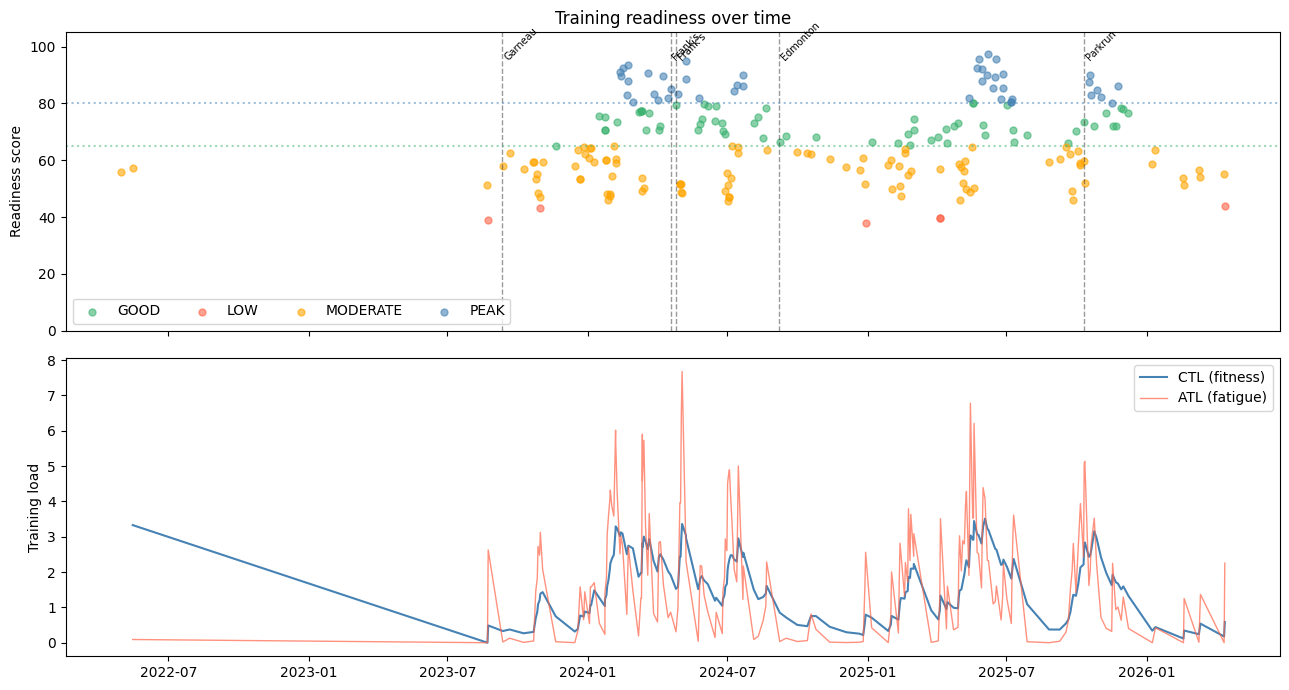

In [11]:
# ── Readiness over time — does it correlate with your race performances? ──────
# Compute readiness for every run in your history
# This is a retrospective validation — did high readiness days precede good races?

readiness_history = []
for _, row in features.sort_values('date').iterrows():
    r = compute_readiness(row.to_dict(), race_df)
    readiness_history.append({
        'date':     row['date'],
        'score':    r['score'],
        'category': r['category'],
        'ctl':      row['ctl_pre'],
        'tsb':      row['tsb_pre'],
    })

rh = pd.DataFrame(readiness_history)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Top: readiness score over time with race markers
colors_map = {'PEAK': 'steelblue', 'GOOD': 'mediumseagreen',
              'MODERATE': 'orange', 'LOW': 'tomato'}
for cat, grp in rh.groupby('category'):
    axes[0].scatter(grp['date'], grp['score'],
                    c=colors_map[cat], label=cat, alpha=0.6, s=25)

# Mark race days
for _, race in race_df.iterrows():
    axes[0].axvline(race['date'], color='black', linestyle='--',
                    alpha=0.4, linewidth=1)
    axes[0].annotate(race['name'].split()[0],
                     (race['date'], 95),
                     fontsize=7, rotation=45, ha='left')

axes[0].axhline(65, color='mediumseagreen', linestyle=':', alpha=0.5)
axes[0].axhline(80, color='steelblue',      linestyle=':', alpha=0.5)
axes[0].set_ylabel('Readiness score')
axes[0].set_title('Training readiness over time')
axes[0].legend(loc='lower left', ncol=4)
axes[0].set_ylim(0, 105)

# Bottom: CTL and ATL for context
axes[1].plot(features['date'], features['ctl_pre'],
             label='CTL (fitness)', color='steelblue', linewidth=1.5)
axes[1].plot(features['date'], features['atl_pre'],
             label='ATL (fatigue)', color='tomato', alpha=0.7, linewidth=1)
axes[1].set_ylabel('Training load')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/readiness_history.png', dpi=120)
plt.show()

In [18]:
def suggest_workout(readiness_result, recent_labels, vdot_result=None):
    """
    Suggest the next workout type based on readiness and recent history.
    
    readiness_result: output of compute_readiness()
    recent_labels: list of recent workout labels, most recent last
                   e.g. ['EASY', 'TEMPO', 'EASY', 'LONG']
    vdot_result: optional, used to suggest specific paces
    
    Logic: rule-based decision tree grounded in periodisation principles.
    We use rules not a model — with 197 runs the sequence patterns
    are too sparse to learn reliably. Rules are interpretable and correct.
    """
    score    = readiness_result['score']
    category = readiness_result['category']
    tsb      = readiness_result['tsb']
    ctl      = readiness_result['ctl']

    # Analyse recent history
    n_recent = min(7, len(recent_labels))
    recent   = recent_labels[-n_recent:] if recent_labels else []

    recent_hard = sum(1 for l in recent if l in ('TEMPO', 'INTERVAL'))
    recent_long = sum(1 for l in recent if l == 'LONG')
    last        = recent[-1] if recent else None
    second_last = recent[-2] if len(recent) >= 2 else None

    suggestion  = None
    reason      = None
    paces       = None

    # ── Rule 1: Low readiness → always EASY ──────────────────────────────────
    if score < 45:
        suggestion = 'EASY'
        reason = (f"Readiness is low ({score:.0f}/100). "
                  f"Your body needs recovery before quality work.")

    # ── Rule 2: Never hard back-to-back ──────────────────────────────────────
    elif last in ('TEMPO', 'INTERVAL'):
        suggestion = 'EASY'
        reason = (f"Your last run was {last}. "
                  f"At least one easy day between hard efforts reduces injury risk.")

    # ── Rule 3: Long run spacing — once per week maximum ─────────────────────
    elif last == 'LONG' or second_last == 'LONG':
        if score >= 65:
            suggestion = 'EASY'
            reason = "Recovery run after your long effort. Keep it genuinely easy."
        else:
            suggestion = 'EASY'
            reason = "Still recovering from your long run. Easy only."

    # ── Rule 4: High readiness + no recent hard work → quality session ────────
    elif score >= 80 and recent_hard == 0:
        # Alternate between TEMPO and INTERVAL based on recent history
        # If haven't done intervals in a while, suggest them
        recent_intervals = sum(1 for l in recent if l == 'INTERVAL')
        if recent_intervals == 0 and ctl > 1.0:
            suggestion = 'INTERVAL'
            reason = (f"Peak readiness ({score:.0f}/100) and no recent intervals. "
                      f"Good time for speed work.")
        else:
            suggestion = 'TEMPO'
            reason = (f"Peak readiness ({score:.0f}/100). "
                      f"Sustained tempo effort will build threshold fitness.")

    # ── Rule 5: Good readiness + one recent hard session → easy or long ───────
    elif score >= 65 and recent_hard == 1:
        if recent_long == 0 and ctl > 0.8:
            suggestion = 'LONG'
            reason = (f"Good readiness ({score:.0f}/100), no long run this week, "
                      f"and solid fitness base. Long run will build aerobic capacity.")
        else:
            suggestion = 'EASY'
            reason = (f"Good readiness ({score:.0f}/100) but recent hard effort. "
                      f"Easy run maintains volume without adding stress.")

    # ── Rule 6: Good readiness + already done hard + long → easy ─────────────
    elif score >= 65 and recent_hard >= 2:
        suggestion = 'EASY'
        reason = (f"You've done {recent_hard} hard sessions recently. "
                  f"Back off and let the adaptation happen.")

    # ── Default: moderate readiness → easy ────────────────────────────────────
    else:
        suggestion = 'EASY'
        reason = (f"Moderate readiness ({score:.0f}/100). "
                  f"Easy running builds base without digging a deeper hole.")

    # ── Pace guidance from VDOT ───────────────────────────────────────────────
    if vdot_result is not None:
        vdot = vdot_result['vdot_estimate']
        # Jack Daniels training paces derived from VDOT
        # Easy: 59-74% vVO2max — roughly 70-75s/km slower than 5km race pace
        t_5k    = predict_time_from_vdot(vdot, 5000)
        pace_5k = t_5k / 5.0

        pace_guidance = {
            'EASY':     (pace_5k + 1.5, pace_5k + 2.5),   # 90-150s/km slower than 5km
            'LONG':     (pace_5k + 1.2, pace_5k + 2.0),   # similar to easy
            'TEMPO':    (pace_5k + 0.3, pace_5k + 0.8),   # comfortably hard
            'INTERVAL': (pace_5k - 0.2, pace_5k + 0.2),   # 5km race pace ± 12s
        }

        lo, hi = pace_guidance[suggestion]

        def fmt_pace(p):
            m = int(p)
            s = int((p - m) * 60)
            return f"{m}:{s:02d}"

        paces = f"{fmt_pace(lo)} – {fmt_pace(hi)} min/km"

    return {
        'suggestion': suggestion,
        'reason':     reason,
        'paces':      paces,
        'readiness':  score,
        'category':   category,
    }


# Test with your actual recent workout history
recent_labels = (features.sort_values('date')
                          .tail(7)['label']
                          .tolist())

print(f"Recent 7 workouts: {recent_labels}")
print()

suggestion = suggest_workout(readiness, recent_labels, vdot_est)

print(f"Workout Suggestion")
print(f"{'─'*40}")
print(f"Suggested:  {suggestion['suggestion']}")
print(f"Readiness:  {suggestion['readiness']:.0f}/100 [{suggestion['category']}]")
if suggestion['paces']:
    print(f"Target pace: {suggestion['paces']}")
print(f"\nReason: {suggestion['reason']}")

Recent 7 workouts: ['TEMPO', 'INTERVAL', 'EASY', 'EASY', 'EASY', 'INTERVAL', 'TEMPO']

Workout Suggestion
────────────────────────────────────────
Suggested:  EASY
Readiness:  44/100 [LOW]
Target pace: 6:07 – 7:07 min/km

Reason: Readiness is low (44/100). Your body needs recovery before quality work.


In [16]:
# In your notebook — check if label is in features
print(features.columns.tolist())
print('label' in features.columns)

['file_stem', 'date', 'distance_km', 'moving_time_min', 'elevation_gain_m', 'hr_max', 'relative_effort', 'calories', 'moving_ratio', 'pace_mean', 'pace_std', 'pace_cv', 'pace_p10', 'pace_p90', 'hr_std', 'hr_max_recorded', 'hr_coverage', 'hr_zone1_frac', 'hr_zone2_frac', 'hr_zone3_frac', 'hr_zone4_frac', 'hr_zone5_frac', 'hr_pace_decoupling', 'cadence_std', 'elevation_gain_stream', 'elevation_loss_stream', 'moving_frac', 'atl_pre', 'ctl_pre', 'tsb_pre', 'weekly_km_7d', 'runs_7d', 'days_since_last_run', 'weekly_km_delta_pct', 'hr_mean', 'cadence_mean', 'has_hr', 'has_cadence', 'has_gps', 'hr_hard_frac', 'label']
True


In [15]:
# Re-apply labels — same logic as Phase 3
features['hr_hard_frac'] = features['hr_zone4_frac'] + features['hr_zone5_frac']

LONG_DIST_KM    = 10.0
INTERVAL_CV     = 0.35
INTERVAL_Z5     = 0.15
TEMPO_HARD_FRAC = 0.85
TEMPO_CV_MAX    = 0.30
TEMPO_MIN_DIST  = 3.0

def label_run(row):
    cv    = row['pace_cv']
    dist  = row['distance_km']
    z5    = row['hr_zone5_frac']
    hard  = row['hr_hard_frac']
    has_hr = row['has_hr']
    if has_hr:
        if cv > INTERVAL_CV and z5 > INTERVAL_Z5:    return 'INTERVAL'
        if cv > INTERVAL_CV * 1.4:                   return 'INTERVAL'
    else:
        if cv > INTERVAL_CV * 1.4:                   return 'INTERVAL'
    if dist >= LONG_DIST_KM:                         return 'LONG'
    if has_hr and hard > TEMPO_HARD_FRAC and cv < TEMPO_CV_MAX and dist >= TEMPO_MIN_DIST:
        return 'TEMPO'
    return 'EASY'

features['label'] = features.apply(label_run, axis=1)
features.to_csv('../data/processed/features.csv', index=False)
print(features['label'].value_counts())

label
EASY        113
INTERVAL     40
TEMPO        36
LONG         22
Name: count, dtype: int64


In [17]:
recent_labels = (features.sort_values('date')
                          .tail(7)['label']
                          .tolist())
print(f"Recent 7 workouts: {recent_labels}")
suggestion = suggest_workout(readiness, recent_labels, vdot_est)

print(f"\nWorkout Suggestion")
print(f"{'─'*40}")
print(f"Suggested:   {suggestion['suggestion']}")
print(f"Readiness:   {suggestion['readiness']:.0f}/100 [{suggestion['category']}]")
if suggestion['paces']:
    print(f"Target pace: {suggestion['paces']}")
print(f"\nReason: {suggestion['reason']}")

Recent 7 workouts: ['TEMPO', 'INTERVAL', 'EASY', 'EASY', 'EASY', 'INTERVAL', 'TEMPO']

Workout Suggestion
────────────────────────────────────────
Suggested:   EASY
Readiness:   44/100 [LOW]
Target pace: 6:07 – 7:07 min/km

Reason: Readiness is low (44/100). Your body needs recovery before quality work.
